# CONCEPTUAL

## 1 Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by (5.6) does indeed minimize Var(αX + (1 − α)Y ).

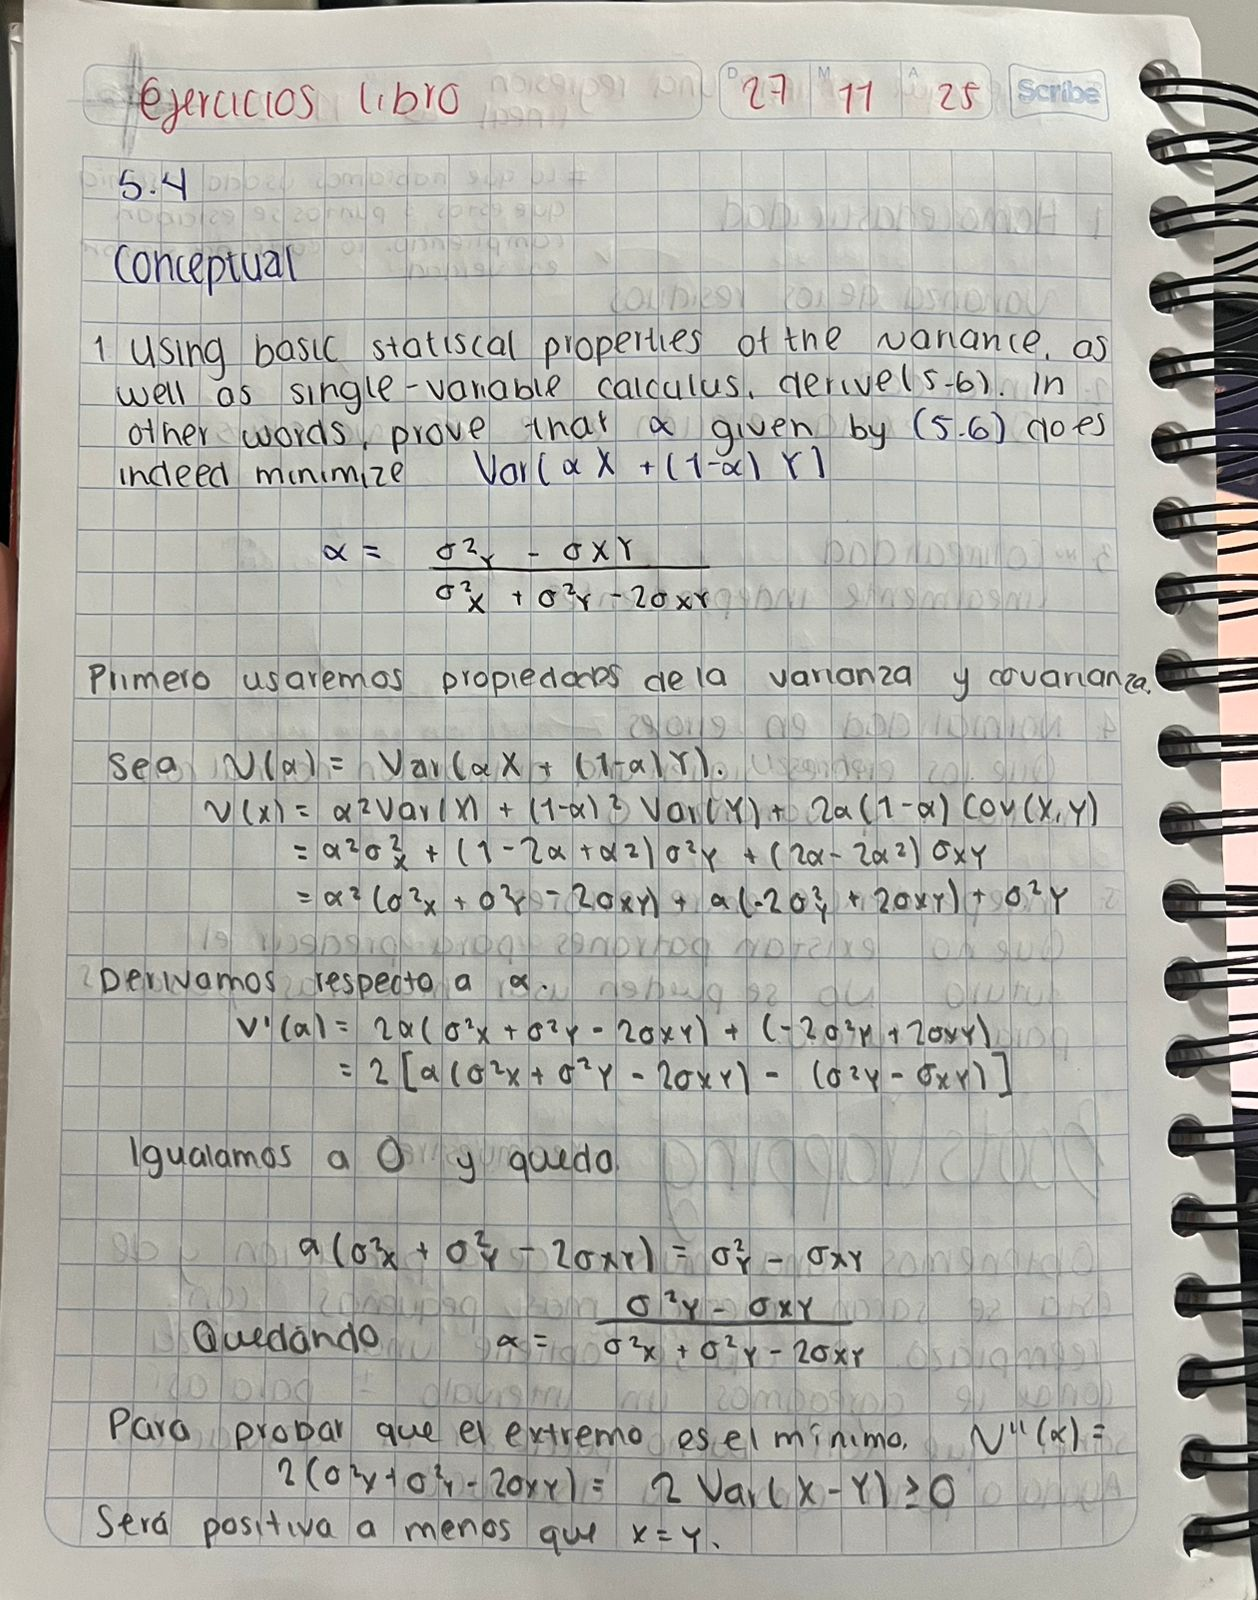

## 2. We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of n observations.

###  a) What is the probability that the first bootstrap observation is not the jth observation from the original sample? Justify your answer.

In [1]:
import pandas as pd
from sklearn.utils import resample
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [4]:
adv = pd.read_csv("Advertising.csv")


n = len(adv)
j = 3
B = 10000

count_not_j = 0

for i in range(B):
    sample = resample(adv)
    first_obs = sample.index[0]
    original_j = adv.index[j-1]

    if first_obs != original_j:
        count_not_j += 1

prob_simulada = count_not_j / B
prob_teorica = (n - 1) / n

print("Probabilidad teórica :", prob_teorica)
print("Probabilidad simulada:", prob_simulada)


Probabilidad teórica : 0.995
Probabilidad simulada: 0.9959


### b) What is the probability that the second bootstrap observation is not the jth observation from the original sample?

In [5]:
n = len(adv)
j = 5
B = 10000

count_not_j = 0
for _ in range(B):
    sample = resample(adv)
    if sample.index[1] != adv.index[j-1]:
        count_not_j += 1

print("Teórica:", (n-1)/n)
print("Simulada:", count_not_j / B)


Teórica: 0.995
Simulada: 0.9952


Básicamente es la misma probabilidad, porque al ser método bootstrap, cualquier observación tiene la misma probabilidad puesto que son independientes y con reemplazo.

### c) Argue that the probability that the jth observation is not in the bootstrap sample is (1 − 1/n)n.

In [6]:
n = len(adv)
j = 10
B = 10000

count_not_present = 0

for i in range(B):
    sample = resample(adv)

    # Si la observación j NO está en el bootstrap
    if adv.index[j-1] not in sample.index:
        count_not_present += 1

prob_simulada = count_not_present / B
prob_teorica = (1 - 1/n)**n

print("Teórica :", prob_teorica)
print("Simulada:", prob_simulada)


Teórica : 0.36695782172616703
Simulada: 0.3616


En código más o menos se vería así la probabilidad. Pero para explicarlo un poco: el bootstrap al hacerse con reemplazo, las n extracciones que se lleguen a hacer son independientes por lo que las probabilidades pueden multiplicarse. Y la probabilidad de que ninguna de esas sea la j-ésima es justamente (1-1/n) y si deseamos saber cuál es la probabilidad de que ninguna sea la j-ésima tendremos que multiplicarlas todas, o sea, elevarlas a la n.

Un dato importante es que en un boostrap cuando un n es grande, alrededor del 36.8% de las observaciones no aparecen en la muetra, pues al obtener repeticiones puede que no todos los datos se lleguen a utilizar.

### d)When n = 5, what is the probability that the jth observation is in the bootstrap sample?

In [7]:
n = 5
j = 3
B = 10000

count_present = 0

for _ in range(B):
    sample = resample(adv)
    if adv.index[j-1] in sample.index:
        count_present += 1

print("Simulada:", count_present / B)
print("Teórica: ", 1 - (1 - 1/n)**n)


Simulada: 0.6334
Teórica:  0.6723199999999999


En el inciso anterior justo teníamos la probabilidad de que apareciera. Ahora necesitamos la probabilidad de que sí aparezca, teniendo en cuenta la muestra de 5. Por lo que serpa 1 - (1 - 1/n)**n)

### (e) When n = 100, what is the probability that the jth observation is in the bootstrap sample?

In [8]:
n = 100
j = 3
B = 10000

count_present = 0

for _ in range(B):
    sample = resample(adv)
    if adv.index[j-1] in sample.index:
        count_present += 1

print("Simulada:", count_present / B)
print("Teórica: ", 1 - (1 - 1/n)**n)


Simulada: 0.6216
Teórica:  0.6339676587267709


Bueno aquí solo se le modifica el n y vemos que la probabilidad disminuye un poco.

### (f) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

In [9]:
n = 10000
j = 3
B = 10000

count_present = 0

for _ in range(B):
    sample = resample(adv)
    if adv.index[j-1] in sample.index:
        count_present += 1

print("Simulada:", count_present / B)
print("Teórica: ", 1 - (1 - 1/n)**n)


Simulada: 0.6429
Teórica:  0.6321389535670295


Lo que comienzo a ver es que no importa el número de muestras, ya que la probabilidad será la misma, puesto que todas las observaciones son independientes y tienen la misma probabilidad por separado.

### g) Create a plot that displays, for each integer value of n from 1 to 100, 000, the probability that the jth observation is in the bootstrap sample. Comment on what you observe.

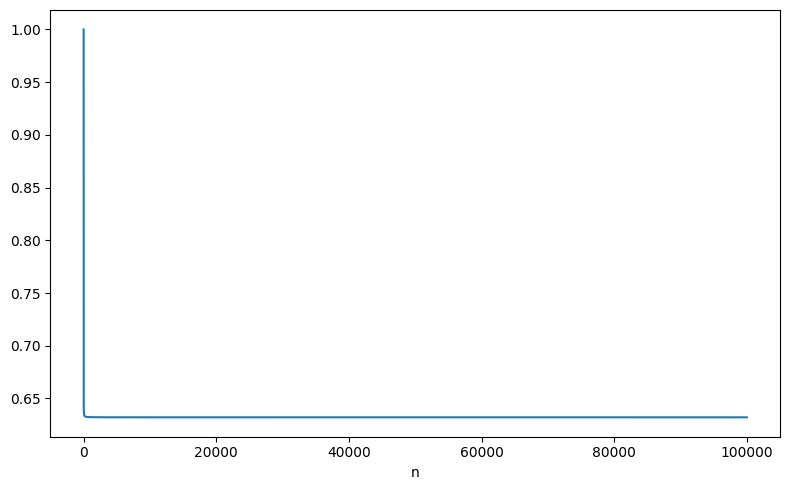

In [10]:
import matplotlib.pyplot as plt

n = np.arange(1, 100001)

probabilities = 1 - (1 - 1/n)**n

plt.figure(figsize=(8,5))
plt.plot(n, probabilities)
plt.xlabel("n")
plt.tight_layout()
plt.show()


Veo aquí en la gráfica que solamente si tenemos una sola muestra la probabilidad de elegir esa será de 1. Pero a medida que aumenta n, aún siendo solo a 2, la probabilidad comienza a centrarse en .63. Esto ocurre porque la probabilidad de que no aparezca converge hacia e a la -1 sienod igual a 0.368 y el complemento sería justo lo que nos está dando en la gráfica (0.632).

### h) We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here j = 4. We first create an array store with values that will subsequently be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we recordcwhether or not the fifth observation is contained in the bootstrap sample.


In [11]:
rng = np.random.default_rng(10)
store = np.empty(10000)
for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0
np.mean(store)

np.float64(0.6362)

Le modifiqué una parte del código, la de agregarle el size de 100, porque justo es lo que faltaba para que utilizara una muestra de 100. Y lo que podemos ver es que se trata del mismo número al que converge cualquier probabilidad de algún número que queramos ver si fue utilizado en el bootstrap.

## 3. We now review k-fold cross-validation
### (a) Explain how k-fold cross-validation is implemented

Primeramente cross validation es una ténica que nos aydua a poder realizar un trabajo/ejercicio en un porcentaje específico de la totalidad de los datos. En el caso de regresiones, nos ayuda a separar el gurpo en dos, evaluar uno de ellos y una vez evaluado y entrenado el modelo, utilizamos esta mitad de los datos para comparar con la otra mitad que no se movió. De esta forma podemos observar que tan bueno fue nuestro modelo. Claro que puede no ser exacto, puesto que la mitad de los datos no tiene porque explicar la otra mitad, pero sí nos puede ayudar a sacar conclusiones y tomar decisiones más fundamentadas.

Aquí es donde entra el k-fold, ya que lo que sucede es que el data set se separa en determinadas partes (K). Un grupo de ellos será el grupo de test y todos los demás los de entrenamiento. Luego entrenamos el modelo con cada grupo y al final los comparamos con el que quedó fuera (test). En esa comparación utilizamos la métrica que deseemos o la que más nos convenga según lo que estemos analizando. Luego se va rotando el lugar de ese grupo test con el objetivo de que cada grupo k sea utilizado como el test de verificación, cono el cual comparar. Y al final promediamos estos resultados para obtener mayor precisión.

### (b) What are the advantages and disadvantages of k-fold crossvalidation relative to:
- **i. The validation set approach?**

Ventajas: primero que anda el k-fold al ser entrenado muchas más veces ayuda a que se tenga mayor precisión. Cada grupo juega el mismo papel y logra un mayor rendimiento y acercamiento. En el validation approach se depende mucho de la manera en la que se dividieron los datos. Puede pasar que los grupos divididos sean muy diferentes y que no se puedan explicar entre si. Además, solamente se hace una partición, y los datos o los grupos solo juegan el papel que se les determina desde el principio.

Desventajas: k-folds puede llegar a ser más tardado por la tanta división que se haga. Más costoso computacionalmente. Aunque claro esto depende mucho de cuanto k tengamos, pero al menos es común que existan más que en el validation approach.

- **ii. LOOCV?**

Ventajas:  el k-folds es más rápido porque no se entrena con la longitud de n. No es tan necesario entrenar con cada n, sino que a veces con un  k = 5,10 es suficiente para obtener un buen desempeño del modelo.

Desventajas: k-folds puede tener más sesgo al no ser entrenado con todo como pasa en LOOVC.

## 4. Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X. Carefully describe how we might estimate the standard deviation of our prediction

Podríamos hacerlo por medio de bootstrap. Primero generamos una cantidad adecuada de muestras bootstrap del conjunto de datos. Luego de cada muestra vamos a utiilizar el método de aprendizaje estadístico, digamos regresión lineal. Esto nos dará una predicción de cada muuestra. Y de cada predicción le sacaremos la desviación estándar, de la cual le sacamos el promedio. Esa desviación estándar será una estimación de la sd de la prediccíon en el punto x.

# APPLIED

## 5. In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

### (a) Fit a logistic regression model that uses income and balance to predict default.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Default.csv to Default.csv


In [16]:
data = pd.read_csv("Default.csv")
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [17]:
data['default'] = data['default'].map({'No':0, 'Yes':1})


x = data[['income', 'balance']]
y = data['default']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [18]:
lr = LogisticRegression()
lr.fit(X_scaled, y)

LogisticRegression()

## b) Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

- i. Split the sample set into a training set and a validation set.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

- ii. Fit a multiple logistic regression model using only the training observations.

In [20]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

- iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.

In [21]:
y_pred = lr.predict_proba(X_test)[:, 1]

preds = (y_pred > 0.5).astype(int)

results = pd.DataFrame({
    'Prob_Default': y_pred,
    'Predicted_Default_0_1': preds,
    'Actual_Default': y_test.values
})

results.head()


,Prob_Default,Predicted_Default_0_1,Actual_Default
0,0.059065,0,0
1,0.001842,0,0
2,0.000017,0,0
3,0.000039,0,0
4,0.053893,0,0


- iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
validation_error = 1 - accuracy

validation_error


0.026666666666666616

### (c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

In [23]:
validation_errors = []

for i in [1, 2, 3]:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=i)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs > 0.5).astype(int)

    accuracy = accuracy_score(y_test, preds)
    val_error = 1 - accuracy

    validation_errors.append(val_error)

validation_errors


[0.024333333333333318, 0.023666666666666614, 0.02533333333333332]

Vemos que los errores se parecen mucho puesto que lo único que varía es la aleatoriedad de cómo se hace el split de los datos. Sin emabrgo, el hecho de no tener una varianza alta hace que la elección de como hacer el split no importe tanto.

### d)  Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate

In [24]:
data = pd.read_csv("Default.csv")

data['default'] = data['default'].map({'No':0, 'Yes':1})

data = pd.get_dummies(data, columns=['student'], drop_first=True)

x =  data.drop("default", axis=1)
y = data['default']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, preds)
val_error = 1 - accuracy

val_error

0.02633333333333332

Pues de hecho el haber incluído la variable student hace que el error aumente un poco, así que creo que lo mejor es dejarlo afuera. No está proporcionando mucha información valiosa.

## 6. We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your analysis.

### (a) Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors

In [25]:
import statsmodels.api as sm

data = pd.read_csv("Default.csv")

data["default_"] = (data["default"] == "Yes").astype(int)

X = data[["income", "balance"]]
X = sm.add_constant(X)

y = data["default_"]


model = sm.GLM(y, X)
results = model.fit()

print(results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               default_   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                        0.028217
Method:                          IRLS   Log-Likelihood:                 3651.3
Date:                Sat, 29 Nov 2025   Deviance:                       282.08
Time:                        02:48:38   Pearson chi2:                     282.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1316
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0922      0.006    -15.936      0.0

### (b) Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model.

In [26]:
def boot_fn(data, index):
    sample = data.iloc[index]

    X = sample[['income', 'balance']].astype(float)
    X = sm.add_constant(X).astype(float)

    y = sample['default_'].astype(float)   # USAR default_ !!!

    model = sm.GLM(y, X, family=sm.families.Binomial())
    result = model.fit()

    return result.params.values


### (c) Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance

In [27]:
np.random.seed(1)
B = 1000
boot_coefs = []

for i in range(B):
    idx = resample(np.arange(len(data)))
    coefs = boot_fn(data, idx)
    boot_coefs.append(coefs)

boot_coefs = np.array(boot_coefs)
boot_se = boot_coefs.std(axis=0)
boot_se

array([4.48774827e-01, 5.02857778e-06, 2.32794756e-04])

### (d) Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.

Al parecer los errores se incrementaron en el boostrap. Aún así son bajos, pero si se alcanza a ver la diferencia.
El boostrap lo que hace es estimar la variabilidad nomás repitiendo el mismo proceso con varias muestras, lo que de alguna forma captura más la incertidumbre real. Y en el GLM utiliza una fórmula basada en supuestos teóricos que incluye independencia, correcta especificaicón del modelo, varianza correcta, entonces los SE quedan un tanto subestimados.
Boostrap detecta mucho más la variabilidad y es además más real que la que GLM está reportando.

## 7. In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function can be used in order to compute the LOOCV test error estimate. Alternatively, one could compute those quantities using just sm.GLM() and the predict() method of the fitted model within a for loop. You will now take this approach in order to compute the LOOCV error for a simple logistic regression model on the Weekly data set. Recall that in the context of classification problems, the LOOCV error is given in (5.4).

### (a) Fit a logistic regression model that predicts Direction using Lag1 and Lag2.

In [29]:
from google.colab import files
uploaded = files.upload()

Saving Weekly.csv to Weekly.csv


In [30]:
weekly = pd.read_csv("Weekly.csv")
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [31]:
weekly['Direction_binary'] = (weekly['Direction'] == 'Up').astype(int)

x = weekly[['Lag1', 'Lag2']]
X = sm.add_constant(x)

y = weekly['Direction_binary']

LOOCV_errors = []

for i in range(len(weekly)):
    X_train = X.drop(i)
    X_test = X.iloc[[i]]

    y_train = y.drop(i)
    y_test = y.iloc[[i]]

    model = sm.GLM(y_train, X_train)
    result = model.fit()

    y_pred_prob = result.predict(X_test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    error = (y_pred != y_test).astype(int).values[0]
    LOOCV_errors.append(error)

LOOCV_error_rate = np.mean(LOOCV_errors)
LOOCV_error_rate

np.float64(0.44811753902662993)

### (b) Fit a logistic regression model that predicts Direction using Lag1 and Lag2 using all but the first observation

In [32]:
X_train = weekly[['Lag1', 'Lag2']].iloc[1:]
y_train = weekly['Direction_binary'].iloc[1:]

X_train = sm.add_constant(X_train)

model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
print(model.summary())

X_test = weekly[['Lag1', 'Lag2']].iloc[[0]]
X_test = sm.add_constant(X_test, has_constant='add')

y_test_pred_prob = model.predict(X_test)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)


print("Probabilidad de 'Up':", y_test_pred_prob.values[0])
print("Predicción final (0=Down, 1=Up):", y_test_pred.values[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Direction_binary   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Sat, 29 Nov 2025   Deviance:                       1486.5
Time:                        02:49:45   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.0

### (c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?

In [33]:
X_test = weekly[['Lag1', 'Lag2']].iloc[[0]]
X_test = sm.add_constant(X_test, has_constant='add')

y_test_pred_prob = model.predict(X_test)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

y_real = weekly['Direction_binary'].iloc[0]

print("Probabilidad de 'Up':", y_test_pred_prob.values[0])
print("Predicción final (0=Down, 1=Up):", y_test_pred.values[0])
print("Valor real (0=Down, 1=Up):", y_real)

# ¿Fue correctamente clasificada?
if y_test_pred.values[0] == y_real:
    print("La primera observación fue correctamente clasificada")
else:
    print("La primera observación no fue correctamente clasificada")


Probabilidad de 'Up': 0.5713923205204429
Predicción final (0=Down, 1=Up): 1
Valor real (0=Down, 1=Up): 0
La primera observación no fue correctamente clasificada


### (d) Write a for loop from i = 1 to i = n, where n is the number of observations in the data set, that performs each of the following steps:

- i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.

In [34]:
weekly['Direction_binary'] = (weekly['Direction'] == 'Up').astype(int)

n = len(weekly)
correct = []

for i in range(n):
    X_train = weekly[['Lag1', 'Lag2']].drop(i)
    y_train = weekly['Direction_binary'].drop(i)

    X_train = sm.add_constant(X_train, has_constant='add')

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

    X_test = weekly[['Lag1', 'Lag2']].iloc[[i]]
    X_test = sm.add_constant(X_test, has_constant='add')

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    y_real = weekly['Direction_binary'].iloc[i]
    correct.append(y_pred.values[0] == y_real)

LOOCV_error = 1 - np.mean(correct)
LOOCV_error


np.float64(0.4499540863177227)

- ii. Compute the posterior probability of the market moving up for the ith observation.


In [35]:
# Convertir 'Direction' a variable binaria: Up = 1, Down = 0
weekly['Direction_binary'] = (weekly['Direction'] == 'Up').astype(int)

n = len(weekly)
posterior_probs = []
correct = []

for i in range(n):
    X_train = weekly[['Lag1', 'Lag2']].drop(i)
    y_train = weekly['Direction_binary'].drop(i)
    X_train = sm.add_constant(X_train, has_constant='add')

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

    X_test = weekly[['Lag1', 'Lag2']].iloc[[i]]
    X_test = sm.add_constant(X_test, has_constant='add')

    y_pred_prob = model.predict(X_test)
    posterior_probs.append(y_pred_prob.values[0])

    y_pred = (y_pred_prob >= 0.5).astype(int)
    y_real = weekly['Direction_binary'].iloc[i]
    correct.append(y_pred.values[0] == y_real)

LOOCV_error = 1 - np.mean(correct)
LOOCV_error

np.float64(0.4499540863177227)

- iii. Use the posterior probability for the ith observation in order to predict whether or not the market moves up

In [36]:
predictions = []

for i in range(n):
    X_train = weekly[['Lag1', 'Lag2']].drop(i)
    y_train = weekly['Direction_binary'].drop(i)
    X_train = sm.add_constant(X_train, has_constant='add')

    model = sm.GLM(y_train, X_train).fit()

    X_test = weekly[['Lag1', 'Lag2']].iloc[[i]]
    X_test = sm.add_constant(X_test, has_constant='add')
    y_pred_prob = model.predict(X_test)

    if y_pred_prob.values[0] >= 0.5:
        predictions.append("Up")
    else:
        predictions.append("Down")

print(predictions[:10])


['Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up']


- iv. Determine whether or not an error was made in predicting the direction for the ith observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

In [37]:
errors = []

for i in range(n):
    X_train = weekly[['Lag1', 'Lag2']].drop(i)
    y_train = weekly['Direction_binary'].drop(i)
    X_train = sm.add_constant(X_train, has_constant='add')

    model = sm.GLM(y_train, X_train).fit()

    X_test = weekly[['Lag1', 'Lag2']].iloc[[i]]
    X_test = sm.add_constant(X_test, has_constant='add')
    y_pred_prob = model.predict(X_test)

    y_pred = 1 if y_pred_prob.values[0] >= 0.5 else 0

    y_real = weekly['Direction_binary'].iloc[i]
    error = 1 if y_pred != y_real else 0
    errors.append(error)

print(errors[:10])


[1, 1, 0, 1, 0, 1, 0, 0, 0, 1]


### (e) Take the average of the n numbers obtained in (d)iv in order to obtain the LOOCV estimate for the test error. Comment on the results.

In [38]:
LOOCV_error = np.mean(errors)
LOOCV_error

np.float64(0.44811753902662993)

Este número nos dice la proporción de observaciones que fueron incorrectamente clasificadas. Esto teniendo en cuenta que se hizo el LOOCV de cada una.

En este caso, obteniendo 0.45 decimos que aproximadamente 45% de las predicciones fueron incorrectas, o sea que el modelo tiene una precisión del 55%.

Con este porcentaje diría que el modelo no tiene un poder predicitvo muy fuerte, casi es un 50-50.

## 8. We will now perform cross-validation on a simulated data set

### (a) Generate a simulated data set as follows:

In [39]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

- In this data set, what is n and what is p? Write out the model used to generate the data in equation form.

n --> número de filas del data set
N sería aquí igual a 100 puesto que la x,y son también 100.
p -->  número de características
Solo tenemos una x así que p = 1.

El modelo usado para generar los datos es:

$$
y_i = x_i - 2 x_i^2 + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma^2)
$$

Aquí x_i es el valor predictor para la observación_1. La e corresponde al error y y la respuesta para al misma observación.

### (b) Create a scatterplot of X against Y . Comment on what you find.

Text(0, 0.5, 'Y')

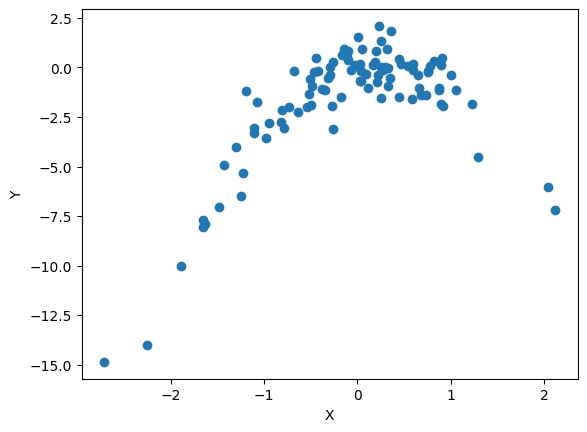

In [40]:
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")

Vemos aquí como si los datos se estuviesen ajustando a una parábola, esto gracias al grado de potencia que tenemos en la ecuación. Además, la relación entre estas 2 variables no es lineal.

### (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

GRADO 1
$$
Y = β_0 + β_1X +  \epsilon
$$
GRADO 2
$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon
$$
GRADO 3
$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon
$$

GRADO 4
$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon
$$


In [41]:
data = pd.DataFrame({'X': x, 'Y': y})

def loocv_error(df, degree):
    n = len(df)
    errors = []

    for i in range(n):
        train = df.drop(i)
        test = df.iloc[[i]]

        X_train = np.vander(train['X'], N=degree+1, increasing=True)
        y_train = train['Y']

        model = sm.OLS(y_train, X_train).fit()

        X_test = np.vander(test['X'], N=degree+1, increasing=True)
        y_test = test['Y'].values

        y_pred = model.predict(X_test)
        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

loocv_1 = loocv_error(data, degree=1)
loocv_2 = loocv_error(data, degree=2)
loocv_3 = loocv_error(data, degree=3)
loocv_4 = loocv_error(data, degree=4)

print("LOOCV Error (Linear):", loocv_1)
print("LOOCV Error (Quadratic):", loocv_2)
print("LOOCV Error (Cubic):", loocv_3)
print("LOOCV Error (Quartic):", loocv_4)


LOOCV Error (Linear): 6.633029839181983
LOOCV Error (Quadratic): 1.1229368563419686
LOOCV Error (Cubic): 1.3017965489358874
LOOCV Error (Quartic): 1.3323942694179305


### (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [42]:
rng = np.random.default_rng(5)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)


data = pd.DataFrame({'X': x, 'Y': y})

def loocv_error(df, degree):
    n = len(df)
    errors = []

    for i in range(n):
        train = df.drop(i)
        test = df.iloc[[i]]

        X_train = np.vander(train['X'], N=degree+1, increasing=True)
        y_train = train['Y']

        model = sm.OLS(y_train, X_train).fit()

        X_test = np.vander(test['X'], N=degree+1, increasing=True)
        y_test = test['Y'].values

        y_pred = model.predict(X_test)
        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

loocv_1 = loocv_error(data, degree=1)
loocv_2 = loocv_error(data, degree=2)
loocv_3 = loocv_error(data, degree=3)
loocv_4 = loocv_error(data, degree=4)

print("LOOCV Error (Linear):", loocv_1)
print("LOOCV Error (Quadratic):", loocv_2)
print("LOOCV Error (Cubic):", loocv_3)
print("LOOCV Error (Quartic):", loocv_4)


LOOCV Error (Linear): 6.089221224990886
LOOCV Error (Quadratic): 1.0537181194875813
LOOCV Error (Cubic): 1.0872514052641022
LOOCV Error (Quartic): 1.2655529775418333


Veo que los errores que obtuve son menores en todos al usar la semilla de 5. Esto pasa porque el conjunto de los datos simulados deja de ser el mismo. La estructura no cambia pero los valores de x y el término de e sí. Pero si observamos en ambos casos el menor error es el cuadrático, mostrando que la verdadera relación entre las variables es de 2do grado.

### (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

Bueno, ya más o menos lo expliqué en el anterior, pero si. Justo en el linear es el que nos da muy alto porque no es capaz de ajustarse a los datos al tener una línea recta. Y al identificar el grado rápidamente podemos interpretar que el menor iba a ser el cuadrático.

### (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

Concluyo que el modelo cuadrático fue el que se ajustó mejor a la regresión de los datos simulados. Este modelo incluye exactamente los términos que fueron generados. Esto refleja que sus coeficientes son estadísticamente significativos y que presentan el menor error en LOOCV.

Los modelos más simples no capturan todos los datos, por ello que el error es mayor. Y los modelos de  grado mayor, utilizan complejidad innecesaria que no resulta significativa, generando un sobreajuste y aumento del error.

Por lo tanto, esta combinación de validación con significancia de coeficientes permite identificar el modelo que ejor se ajusta a la relación de los datos, y nos dice que a veces la complejidad no siempre es mejor.

## 9. We will now consider the Boston housing data set, from the ISLP library

### (a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate µˆ.

In [43]:
from google.colab import files
uploaded = files.upload()

Saving Boston Housing Dataset 1978.xlsx to Boston Housing Dataset 1978.xlsx


In [44]:
boston = pd.read_excel("Boston Housing Dataset 1978.xlsx")
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [45]:
mu_hat = boston['MEDV'].mean()
mu_hat

np.float64(23.750442477876106)

### b)Provide an estimate of the standard error of µˆ. Interpret this result. Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

In [46]:
std = boston['MEDV'].std(ddof=1)
n = len(boston)

SE_mu_hat = std / np.sqrt(n)
SE_mu_hat


np.float64(0.3915901080014807)

### (c) Now estimate the standard error of µˆ using the bootstrap. How does this compare to your answer from (b)?

In [47]:
B = 1000

bootstrap_means = []

for _ in range(B):
    sample = boston['MEDV'].sample(n=len(boston), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

SE_bootstrap = bootstrap_means.std()
SE_bootstrap


np.float64(0.39312209499809725)

Pues es muy similar, diría que casi igual. Por lo tanto, esto nos puede decir lo importante y funcional que puede llegar a ser boostrap por la cercanía a lo que realmente es.

### (d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9).
Hint: You can approximate a 95 % confidence interval using the
formula [ˆµ − 2SE(ˆµ), µˆ + 2SE(ˆµ)].

In [49]:
rng = np.random.default_rng(12345)

mu_hat = boston['MEDV'].mean()
n = len(boston)

s = boston['MEDV'].std(ddof=1)
SE_analytic = s / np.sqrt(n)

B = 10000
bootstrap_means = np.empty(B)
for b in range(B):
    sample = boston['MEDV'].sample(n=n, replace=True, random_state=rng.integers(1<<30))
    bootstrap_means[b] = sample.mean()

SE_bootstrap = bootstrap_means.std(ddof=1)

ci_bootstrap_normal = (mu_hat - 2*SE_bootstrap, mu_hat + 2*SE_bootstrap)
print("IC 95%:", ci_bootstrap_normal)

ci_analytic = (mu_hat - 2*SE_analytic, mu_hat + 2*SE_analytic)
print("IC 95%:", ci_analytic)

IC 95% (bootstrap - approx normal): (np.float64(22.919833082197844), np.float64(24.58105187355437))
IC 95% (analítico, 2*SE analítico): (np.float64(22.967262261873145), np.float64(24.533622693879067))


### (e) Based on this data set, provide an estimate, µˆmed, for the median value of medv in the population

In [50]:
mu_hat_med = boston['MEDV'].median()
mu_hat_med

21.95

### (f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.

In [51]:
rng = np.random.default_rng(1)

B = 10000
n = len(boston)


bootstrap_medians = np.empty(B)

for b in range(B):
    sample = boston['MEDV'].sample(n=n, replace=True, random_state=rng.integers(1<<30))
    bootstrap_medians[b] = sample.median()

SE_median_boot = bootstrap_medians.std(ddof=1)

ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

# Mostrar resultados
print(f"Mediana muestral (hat_mu_med) = {boston['MEDV'].median():.4f}")
print(f"SE (bootstrap) de la mediana = {SE_median_boot:.4f}")

Mediana muestral (hat_mu_med) = 21.9500
SE (bootstrap) de la mediana = 0.3037


### (g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1. (You can use the np.percentile() function.)

In [57]:
boston = pd.read_excel("Boston Housing Dataset 1978.xlsx")

mu_hat_01 = np.percentile(boston['MEDV'].dropna(), 10)
print(f"Estimación del décimo percentil (mu_hat_0.1) = {mu_hat_01:.4f}")

Estimación del décimo percentil (mu_hat_0.1) = 14.5000


### (h) Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your findings.

In [58]:
import numpy as np

medv = boston['MEDV'].dropna().values
B = 1000
boot_percentiles = np.zeros(B)

rng = np.random.default_rng(1)

for b in range(B):
    sample = rng.choice(medv, size=len(medv), replace=True)
    boot_percentiles[b] = np.percentile(sample, 10)

se_boot_01 = boot_percentiles.std()
se_boot_01


np.float64(0.42094620071928424)

El error estándar boostrap del percentil 10 de MEDV me dio de 0.42. Este valor  nos dice que al estimación del percentil 10 presenta una variabilidad un tanto moderada, así que si repitieramos el procedimiento muchas veces el percentil 10 variaría alrededor de 0.42  unidades.